In [1]:
import pandas as pd
from transformers import RobertaTokenizer

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mexwell/fake-reviews-dataset/fake reviews dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [3]:
df['text_'].head()

0    Love this!  Well made, sturdy, and very comfor...
1    love it, a great upgrade from the original.  I...
2    This pillow saved my back. I love the look and...
3    Missing information on how to use it, but it i...
4    Very nice set. Good quality. We have had the s...
Name: text_, dtype: object

In [4]:
print(len(df))

40432


In [5]:
df.dtypes

category     object
rating      float64
label        object
text_        object
dtype: object

In [6]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

# Check the data balance in each column

In [7]:
df['category'].value_counts()

category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: int64

In [8]:
df['rating'].value_counts()

rating
5.0    24559
4.0     7965
3.0     3786
1.0     2155
2.0     1967
Name: count, dtype: int64

In [9]:
df['label'].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

# Preprocessing Dataset (RoBERTa)

In [10]:
# Checking if there are sentences that have multiple spaces
import re

count = 0
for text in df['text_']:
    if re.search(r's{2}', text):
        count += 1
print(count)

9493


In [11]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


### REGEX & CONTRACTION HANDLING

In [12]:
import re
import contractions

clean_text = []

for text in df['text_']:
    # Contraction Handling
    cleaned_text = contractions.fix(text)
    # Removing Punctuation
    cleaned_text = re.sub(r'[^\w\s]', '', cleaned_text)
    # Adding Space (where a space should be)
    cleaned_text = re.sub(r'(?<!^)(?=[A-Z])', ' ', cleaned_text)
    # Removing Extra Spaces
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    clean_text.append(cleaned_text)

print(clean_text[:5])

['Love this Well made sturdy and very comfortable I love it Very pretty', 'love it a great upgrade from the original I have had mine for a couple of years', 'This pillow saved my back I love the look and feel of this pillow', 'Missing information on how to use it but it is a great product for the price I', 'Very nice set Good quality We have had the set for two months now and have not been']


# Tokenizer and Feature Extraction using RoBERTa

### Feature Extraction

In [13]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [14]:
from transformers import pipeline
import numpy as np

feature_extractor = pipeline(
    "feature-extraction",
    framework = "pt",
    model = "FacebookAI/roberta-base",
    device = 0
)

features = []

for feature in feature_extractor(clean_text, return_tensors = "pt", truncation = True, batch_size = 32):
    feature_mean = feature[0].numpy().mean(axis = 0)
    features.append(feature_mean)

features_np = np.array(features) # convert to np array

print(features_np.shape)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

(40432, 768)


# Feature Engineering (Feature transformation)

In [15]:
df.dtypes

category     object
rating      float64
label        object
text_        object
dtype: object

In [16]:
df['category'].unique()

array(['Home_and_Kitchen_5', 'Sports_and_Outdoors_5', 'Electronics_5',
       'Movies_and_TV_5', 'Tools_and_Home_Improvement_5',
       'Pet_Supplies_5', 'Kindle_Store_5', 'Books_5', 'Toys_and_Games_5',
       'Clothing_Shoes_and_Jewelry_5'], dtype=object)

In [17]:
from sklearn.preprocessing import OneHotEncoder


encoded_data = OneHotEncoder().fit_transform(df['category'].values.reshape(-1, 1)).toarray()


print(encoded_data)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [18]:
encoded_data.shape

(40432, 10)

In [19]:
features_np.shape

(40432, 768)

In [20]:
print(df['rating'].shape)

(40432,)


In [21]:
rating = df['rating'].values.reshape(-1, 1)

print(rating.shape)

(40432, 1)


### Concatenation

In [22]:
combined = np.concatenate((encoded_data, rating, features_np), axis = 1)

combined.shape

(40432, 779)

### Convert label

In [23]:
from sklearn.preprocessing import LabelEncoder

encoded_label = LabelEncoder().fit_transform(df['label'])

In [24]:
encoded_label.shape

(40432,)

# XGBoost Hyperparameter Tuning

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [26]:
param_grid = {
    'max_depth': 7, # berapa banyak pertanyaan yang boleh ditanya setiap pohon sblm mengambil decisiom
    'learning_rate': 0.15, # mngontrol seberapa besar kontribusi setiap pohon
    'subsample': 0.7, # nentuin berapa persen data yang diapakai buat ngelatih tiap tree
    'n_estimators': 300 # epochs
}

model = XGBClassifier(
    **param_grid
)

# Model Training & Model Evaluation

In [27]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

In [28]:
scores = []
conf_matrix = []
roc_auc = []
class_rep = []
all_y_test = []
all_y_pred = []

for train_index, test_index in kf.split(combined):
    X_train, X_test, y_train, y_test = combined[train_index], combined[test_index], encoded_label[train_index], encoded_label[test_index]
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))
    y_pred = model.predict(X_test)
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    class_rep.append(classification_report(y_test, y_pred))
    roc_auc.append(roc_auc_score(y_test, y_pred))

### Print Score (Accuracy)

In [29]:
for i, score in enumerate(scores):
    print(f"Score for fold {i}: {score * 100:.2f}%")


Score for fold 0: 91.86%
Score for fold 1: 91.20%
Score for fold 2: 91.22%
Score for fold 3: 91.94%
Score for fold 4: 92.09%
Score for fold 5: 92.90%
Score for fold 6: 90.85%
Score for fold 7: 91.94%
Score for fold 8: 91.42%
Score for fold 9: 91.05%


In [30]:
print(f"Total Scores from all of the folds: {np.mean(scores) * 100:.2f}%")

Total Scores from all of the folds: 91.65%


### Print Confusion Matrix

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix for fold 1


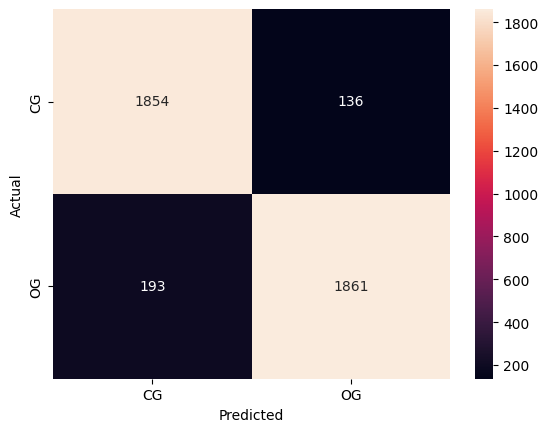

Confusion Matrix for fold 2


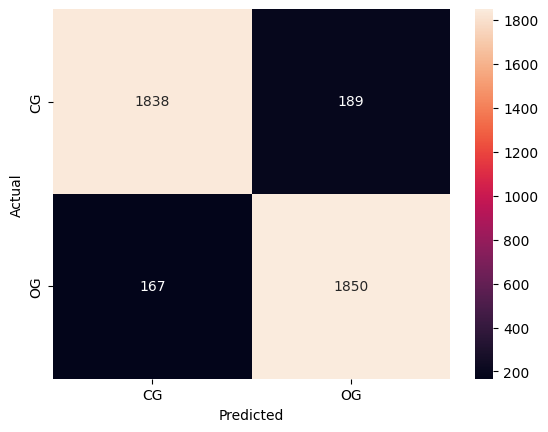

Confusion Matrix for fold 3


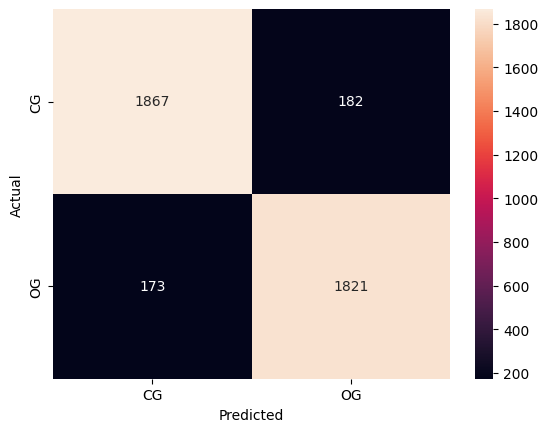

Confusion Matrix for fold 4


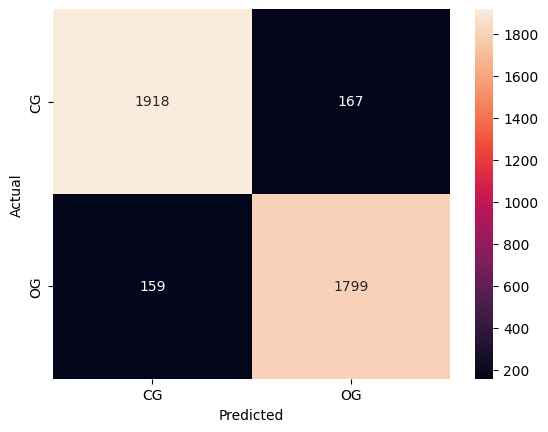

Confusion Matrix for fold 5


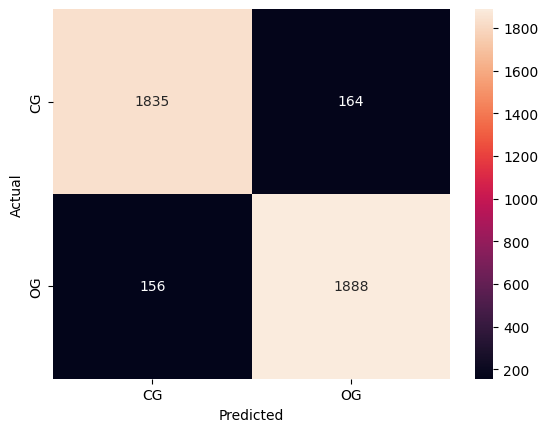

Confusion Matrix for fold 6


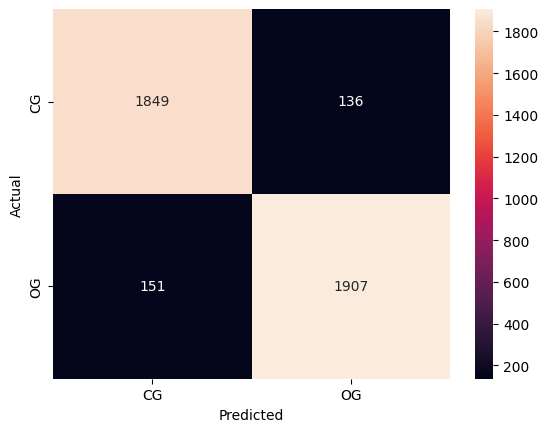

Confusion Matrix for fold 7


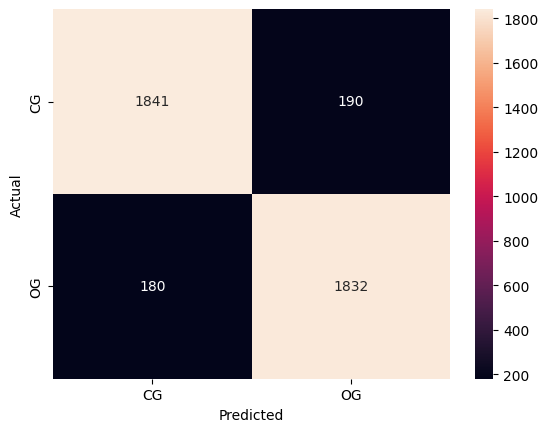

Confusion Matrix for fold 8


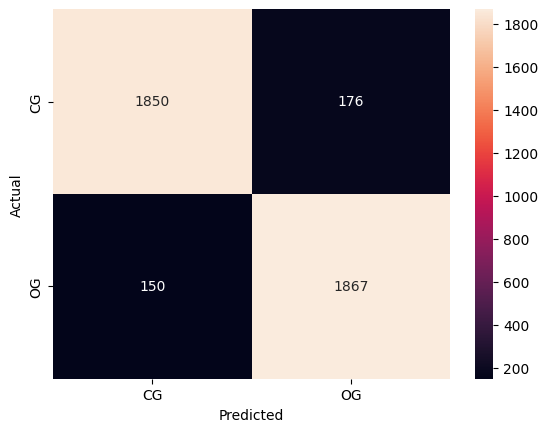

Confusion Matrix for fold 9


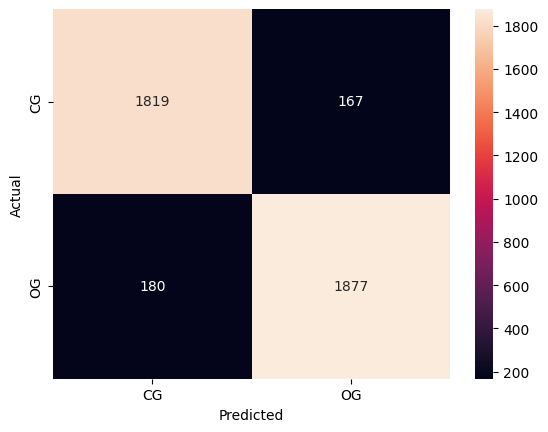

Confusion Matrix for fold 10


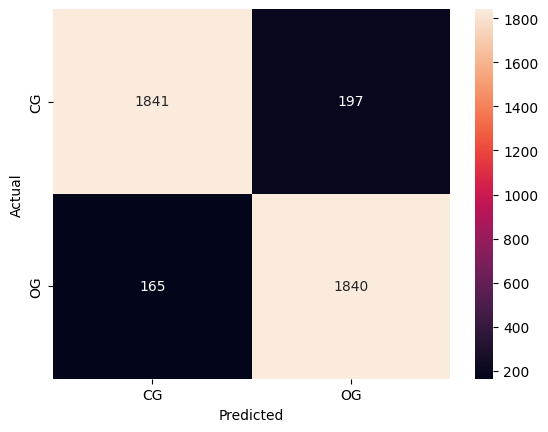

In [32]:
for i, cm in enumerate(conf_matrix):
    print(f"Confusion Matrix for fold {i + 1}")
    sns.heatmap(cm, annot = True, fmt = 'd', xticklabels = ["CG", "OG"], yticklabels = ["CG", "OG"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()                                                                         

Confuison Matrix from total all of the folds


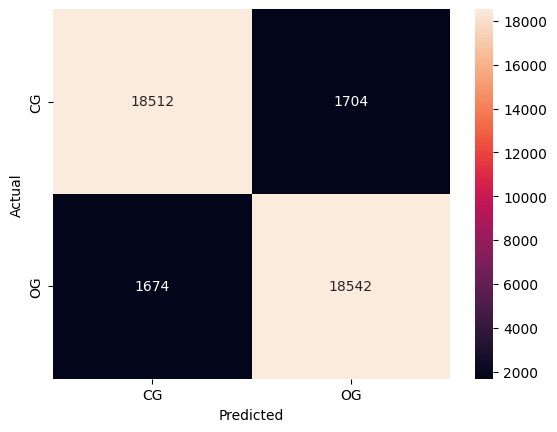

In [33]:
print("Confuison Matrix from total all of the folds")
cm = confusion_matrix(all_y_test, all_y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels = ["CG", "OG"], yticklabels = ["CG", "OG"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Print Classification Report

In [34]:
for i, cr in enumerate(class_rep):
    print(f"Classification Report for fold {i + 1}")
    print(cr)

Classification Report for fold 1
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1990
           1       0.93      0.91      0.92      2054

    accuracy                           0.92      4044
   macro avg       0.92      0.92      0.92      4044
weighted avg       0.92      0.92      0.92      4044

Classification Report for fold 2
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      2027
           1       0.91      0.92      0.91      2017

    accuracy                           0.91      4044
   macro avg       0.91      0.91      0.91      4044
weighted avg       0.91      0.91      0.91      4044

Classification Report for fold 3
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      2049
           1       0.91      0.91      0.91      1994

    accuracy                           0.91      4043
   macro avg       0.91      

In [35]:
print(f"Classification Report from all of the folds")
print(classification_report(all_y_test, all_y_pred))

Classification Report from all of the folds
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     20216
           1       0.92      0.92      0.92     20216

    accuracy                           0.92     40432
   macro avg       0.92      0.92      0.92     40432
weighted avg       0.92      0.92      0.92     40432



### Print ROC AUC Score

In [36]:
for i, ra in enumerate(roc_auc):
    print(f"ROC AUC Score for fold {i + 1}: {ra * 100:.2f}%")

ROC AUC Score for fold 1: 91.88%
ROC AUC Score for fold 2: 91.20%
ROC AUC Score for fold 3: 91.22%
ROC AUC Score for fold 4: 91.93%
ROC AUC Score for fold 5: 92.08%
ROC AUC Score for fold 6: 92.91%
ROC AUC Score for fold 7: 90.85%
ROC AUC Score for fold 8: 91.94%
ROC AUC Score for fold 9: 91.42%
ROC AUC Score for fold 10: 91.05%


In [37]:
print(f"ROC AUC Score from all of the folds: {roc_auc_score(all_y_test, all_y_pred) * 100:.2f}%")

ROC AUC Score from all of the folds: 91.65%


In [38]:
import joblib
from google.colab import files  # If using Colab
# or use this for Kaggle:
# from IPython.display import FileLink

# Train on full dataset first
model.fit(combined, encoded_label)

# Save the model
joblib.dump(model, 'xgboost_roberta_model.pkl')
print("✅ Model saved as 'xgboost_roberta_model.pkl'")

# Download the model
from google.colab import files
files.download('xgboost_roberta_model.pkl')

✅ Model saved as 'xgboost_roberta_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>